<a href="https://colab.research.google.com/github/farahrhma/latihanutsdatmin/blob/main/cobacoba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
print('✅ Library berhasil diimport!')


✅ Library berhasil diimport!


In [4]:
 df = pd.read_csv('student_data.csv')

In [5]:
# Buat ID
df['id'] = range(len(df))

In [6]:
# Buat label dari G3
df['performa'] = df['G3'].apply(lambda x: 'Baik' if x >= 10 else 'Tidak Baik')

In [7]:
print(df.shape)
df.head()

(395, 35)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,id,performa
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,0,Tidak Baik
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,1,Tidak Baik
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,2,Baik
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,3,Baik
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,4,Baik


In [8]:
 print(df['performa'].value_counts())

performa
Baik          265
Tidak Baik    130
Name: count, dtype: int64


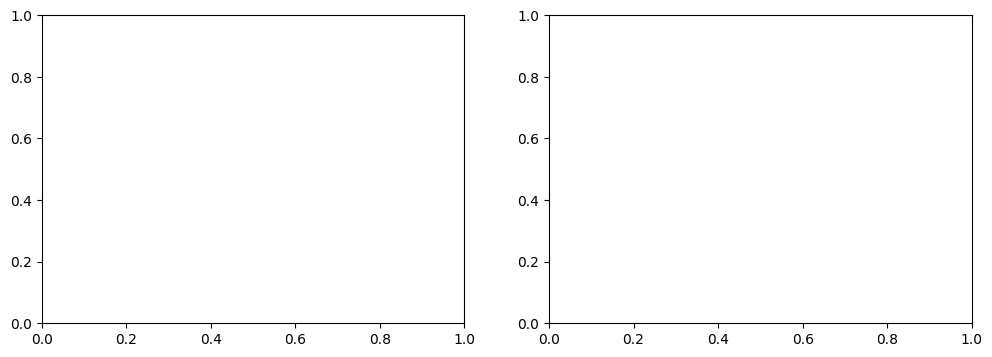

In [9]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

In [10]:
df['performa'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribusi Performa')

Text(0.5, 1.0, 'Distribusi Performa')

In [11]:
num_cols = df.select_dtypes(include=np.number).drop('id', axis=1)
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1])

<Axes: >

In [15]:
plt.show()
# Pisahkan X dan Y
X = df.drop(['id', 'performa', 'G3'], axis=1)
y = df['performa']

In [16]:
# Buat data test (simulasi)
df_test = df.sample(50, random_state=42).copy()
X_test_final = df_test.drop(['id', 'performa', 'G3'], axis=1)

In [17]:
# Encoding Y
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

In [18]:
# Encoding semua kolom kategori
le_dict = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_test_final[col] = le.transform(X_test_final[col])
    le_dict[col] = le

In [20]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

In [21]:
# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [22]:
print("✅ Preprocessing selesai!")

✅ Preprocessing selesai!


In [23]:
 models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}

results = {}

In [25]:
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'model': model, 'acc': acc}
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 87.34%
Decision Tree: 87.34%
Random Forest: 92.41%
KNN: 74.68%


In [27]:
 best_name = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']

In [28]:
best_model

RandomForestClassifier()

In [29]:
print("Model terbaik:", best_name)

Model terbaik: Random Forest


In [30]:
y_pred_val = best_model.predict(X_val)

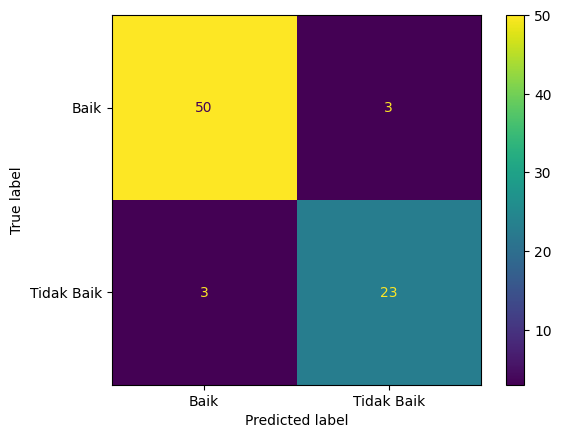

In [31]:
cm = confusion_matrix(y_val, y_pred_val)
ConfusionMatrixDisplay(cm, display_labels=le_y.classes_).plot()
plt.show()

In [32]:
print(classification_report(y_val, y_pred_val, target_names=le_y.classes_))

              precision    recall  f1-score   support

        Baik       0.94      0.94      0.94        53
  Tidak Baik       0.88      0.88      0.88        26

    accuracy                           0.92        79
   macro avg       0.91      0.91      0.91        79
weighted avg       0.92      0.92      0.92        79



In [33]:
# Prediksi data test
y_pred_test = best_model.predict(X_test_scaled)
y_pred_label = le_y.inverse_transform(y_pred_test)

In [34]:
# Simpan hasil
hasil = pd.DataFrame({
    'id': df_test['id'],
    'performa': y_pred_label
})

In [35]:
hasil.to_csv('hasil_prediksi.csv', index=False)

In [36]:
print("✅ CSV berhasil dibuat!")
print(hasil.head())

✅ CSV berhasil dibuat!
      id    performa
78    78        Baik
371  371        Baik
248  248  Tidak Baik
55    55        Baik
390  390  Tidak Baik
